In [2]:
!pip install pandas matplotlib yfinance requests


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import os
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# =========================================================
# 步驟 1：下載並設定字型（直接指定檔案路徑，保證成功）
# =========================================================
font_url = "https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf"
font_path = "SourceHanSerifTW-VF.ttf"

if not os.path.exists(font_path):
    print("正在下載中文字型...")
    os.system(f"wget -O {font_path} {font_url}")

# 建立字型物件
tw_font = FontProperties(fname=font_path)
plt.rcParams["axes.unicode_minus"] = False  # 正常顯示負號

正在下載中文字型...


--2026-06-16 08:22:29--  https://github.com/adobe-fonts/source-han-serif/raw/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf [following]
--2026-06-16 08:22:30--  https://raw.githubusercontent.com/adobe-fonts/source-han-serif/release/Variable/TTF/Subset/SourceHanSerifTW-VF.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16851180 (16M) [application/octet-stream]
Saving to: ‘SourceHanSerifTW-VF.ttf’

     0K .......... .......... .......... .......... ........

正在從 Yahoo Finance 抓取資料...


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_5078/3304459831.py:161: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5078/3304459831.py:161: UserWarning: Glyph 32929 (\N{CJK UNIFIED IDEOGRAPH-80A1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5078/3304459831.py:161: UserWarning: Glyph 22577 (\N{CJK UNIFIED IDEOGRAPH-5831}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5078/3304459831.py:161: UserWarning: Glyph 37228 (\N{CJK UNIFIED IDEOGRAPH-916C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5078/3304459831.py:161: UserWarning: Glyph 25351 (\N{CJK UNIFIED IDEOGRAPH-6307}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5078/3304459831.py:161: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5078

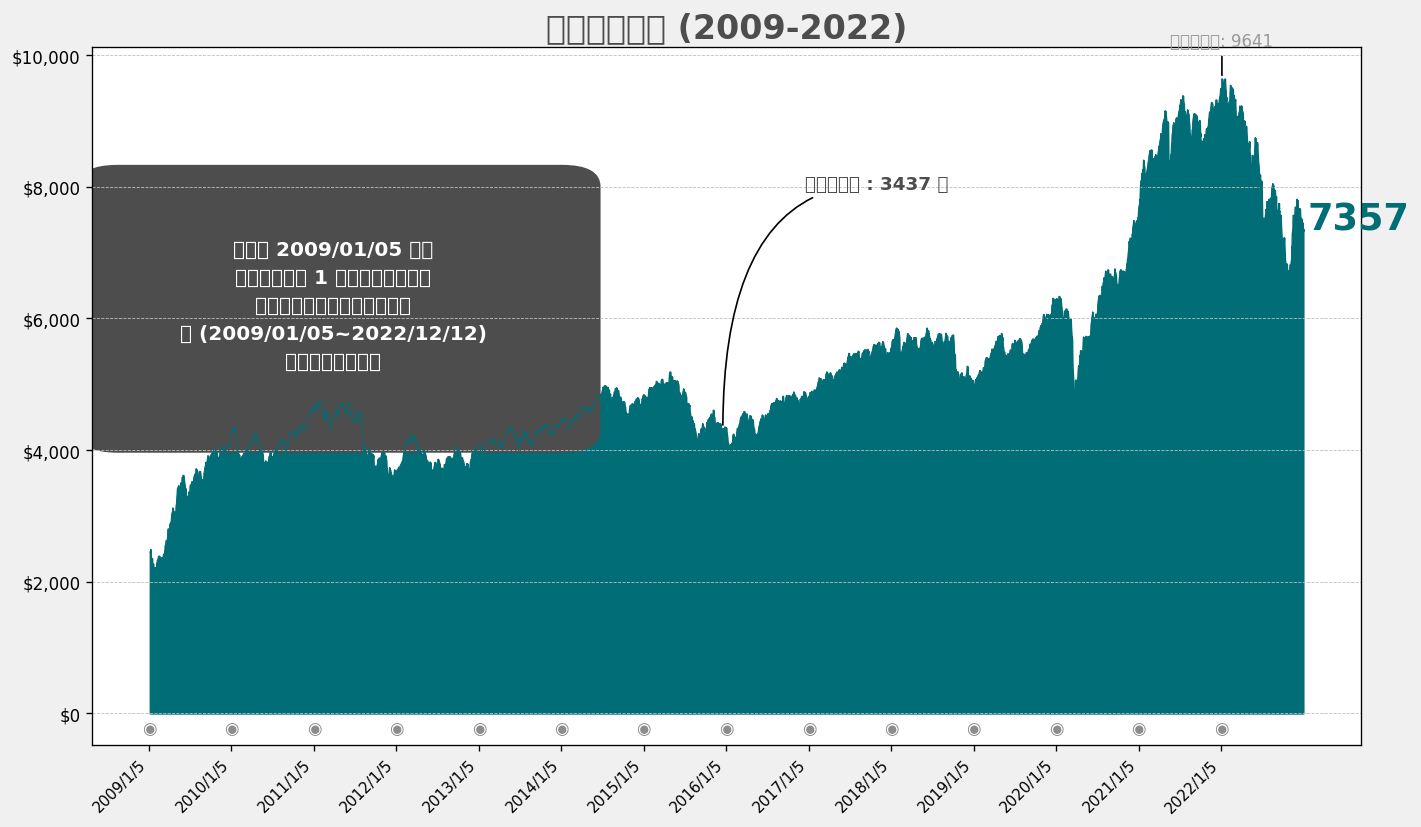

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.font_manager as fm
import os
import requests
from io import BytesIO
import matplotlib.image as mpimg

# ==========================================
# 1. 設置中文字體 (需根據操作系統調整)
# ==========================================
# # 這次使用穩定可靠的字體直連下載點
# font_url = "https://raw.githubusercontent.com/halfofseven/gfont/master/fonts/msjh.ttf"
# font_path = "msjh.ttf"

# if not os.path.exists(font_path):
#     print("正在下載微軟正黑體，請稍候...")
#     r = requests.get(font_url)
#     with open(font_path, "wb") as f:
#         f.write(r.content)
#     print("下載完成！")

# # 關鍵點：建立字體屬性物件 (後續所有的中文都用這個變數來指定)
# my_font = fm.FontProperties(fname=font_path)

# ==========================================
# 2. 獲取並處理資料
# ==========================================
print("正在從 Yahoo Finance 抓取資料...")
# 台股加權指數作為替代 (此處以單次下載資料為例，實務上可串接 API)
ticker = "^TWII"
start_date = "2009-01-01"
end_date = "2023-01-01" # 跨過 2022 年底

# 抓取資料
df = yf.download(ticker, start=start_date, end=end_date)

# 如果下載下來的 DataFrame 有多層索引，將其扁平化
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 計算累積投入資本 (每一天投資 1 元)
df['Daily_Inv'] = 1
df['Cumulative_Inv'] = df['Daily_Inv'].cumsum()

# 模擬一個"累積價值"列，這裡簡單地用指數收盤價來模擬，並根據投入金額做縮放
# 您實務上應使用真正的報酬指數
# 這裡將終值調整為與圖表一致的 7357 元，以此為基準縮放
final_val = 7357
initial_close = df['Close'].iloc[0]
final_close = df['Close'].iloc[-1]
scale_factor = final_val / final_close
df['Value_Sim'] = df['Close'] * scale_factor

# 重新採樣為每年初的數據點，用於 X 軸標籤
yearly_ticks = df.resample('YS').first().index

# ==========================================
# 3. 繪製圖表
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7), dpi=120)
fig.patch.set_facecolor('#f0f0f0') # 設置圖表背景色

# 繪製累積價值區域圖 (深湖綠色)
ax.fill_between(df.index, df['Value_Sim'], color='#006d77', alpha=1.0)
ax.plot(df.index, df['Value_Sim'], color='#006d77', linewidth=0.5)

# ==========================================
# 4. 加入浮動說明文字框
# ==========================================
# 定義框的內容和樣式
info_text = (
    "假設從 2009/01/05 開始\n"
    "每天固定投資 1 元在台股報酬指數\n"
    "不管股市起伏，世界發生什麼\n"
    "在 (2009/01/05~2022/12/12)\n"
    "這段時間，你將："
)
# 建立一個圓角矩形框
rect_box = patches.FancyBboxPatch(
    (0.02, 0.45), 0.35, 0.35, # (x, y), 寬, 高 (使用圖表坐標)
    boxstyle="round,pad=0.03",
    linewidth=1, edgecolor='#4d4d4d', facecolor='#4d4d4d',
    transform=ax.transAxes, # 相對坐標
)
ax.add_patch(rect_box)

# 加入文字到框內
ax.text(
    0.19, 0.63, # 文字框內的相對坐標
    info_text,
    color='white', fontsize=12,
    weight='bold', ha='center', va='center',
    transform=ax.transAxes,
    linespacing=1.6 # 調整行距
)

# ==========================================
# 5. 加入數據標記和示意圖示
# ==========================================

# a) 高點標記 (示意)
max_idx = df['Value_Sim'].idxmax()
max_val = df['Value_Sim'].max()
peak_text = f"最高點曾達: {max_val:.0f}"
ax.annotate(peak_text, xy=(max_idx, max_val), xytext=(max_idx, max_val + 500),
            color='#999999', fontsize=10,
            arrowprops=dict(facecolor='#999999', arrowstyle='-'),
            ha='center')

# b) 終點價值標記 (7357)
final_idx = df.index[-1]
final_val_text = f"{final_val}"
ax.text(
    final_idx + timedelta(days=20), # 調整文字位置
    final_val,
    final_val_text,
    color='#006d77', fontsize=22, weight='bold'
)

# c) 總投入資本標記和圖示 (3437)
invest_total_val = 3437
invest_total_text = f"總投入資本 : {invest_total_val} 元"
invest_idx = df.index[len(df)//2] # 示意位置
invest_val = df.loc[invest_idx, 'Value_Sim']
ax.annotate(
    invest_total_text,
    xy=(invest_idx, invest_val),
    xytext=(invest_idx + timedelta(days=365), invest_val + invest_total_val + 200),
    color='#4d4d4d', fontsize=11, weight='bold',
    arrowprops=dict(facecolor='#4d4d4d', arrowstyle='-', connectionstyle='angle3,angleA=0,angleB=-90')
)

# d) X軸示意小圖示 (以文字標記模擬)
for date in yearly_ticks:
    # 在對應日期下方加上小圓點
    ax.text(date, -300, "◉", fontsize=10, color='#8c8c8c', ha='center')

# ==========================================
# 6. 設定坐標軸、標題和格式
# ==========================================
ax.set_title('台股報酬指數 (2009-2022)', fontsize=20, weight='bold', color='#4d4d4d')

# 設定 Y 軸格式 (加上千分位符號和錢字號)
from matplotlib.ticker import FuncFormatter
def y_axis_format(x, pos):
    return f"${x:,.0f}"
ax.yaxis.set_major_formatter(FuncFormatter(y_axis_format))

# 設定 X 軸格式 (只顯示日期，不顯示年份)
ax.set_xticks(yearly_ticks)
ax.set_xticklabels([d.strftime('%Y/1/5') for d in yearly_ticks], rotation=45, ha='right', fontsize=9)

# 加入網格線
ax.grid(axis='y', linestyle='--', linewidth=0.5, color='#bfbfbf')

# 調整佈局
plt.tight_layout()

# 顯示圖表
plt.show()